# **WEIGHTED MONTE CARLO AND IMPORTANCE SAMPLING**
Let $w = \frac{f}{g}$, where $f$ is the density of $X$ and $g$ is the density of $Y$. Suppose that:

$$
g(y) = 0 \Rightarrow f(y) = 0
$$

Let $y_i$ be a sample from $Y$. Then we call:

$$
\frac{1}{n} \sum_{i=1}^{n} h(y_i) w(y_i)
$$

a weighted Monte Carlo approximation of $\mathbb{E}(h(X))$. The weight $w = \frac{f}{g}$ is called the likelihood ratio.

---
Using general weights $w(\omega_i)$
$$
\frac{1}{n} \sum_{i=1}^{n} h(Y(\omega_i)) w(\omega_i)
$$

- Where $Y(\omega_i)$ is a sample from $Y$.

---
*The weights may be used for different purposes. Example:*

Improving the approximation of $ \mathbb{E}(h(Y)) $

- One may choose the weight in order to correct for numerical errors in the mean (for example, if $\mathbb{E}(Y)$ is known analytically) — this is called **moment matching**.

- One may choose the weight to reduce the variance of the integrand and hence the Monte Carlo approximation error in the estimation of $ \mathbb{E}(h(Y)) $ — this is known as **variance reduction** or **control variates**.

Improving the approximation of $ \mathbb{E}(h(X)) $

$$
w(y) = \frac{f(y)}{g(y)}
$$

results in a Monte Carlo approximation of $ \mathbb{E}(h(X)) $, and can be considered as **importance sampling**, where the random variable $ Y $ has more sample points in "important regions" (important for the valuation function $ h $) compared to the random variable $ X $.

<p align="center">
<img src="image-29.png" width="500">
</p>

## **Importance sampling:**
Let $X$ and $Y$ be two $d$-dimensional integrable random variables.

- Assume that the densities of the distribution of the random variables $X$ and $Y$ are known, being $\phi_X$ and $\phi_Y$ respectively. Then we have:

$$
\mathbb{E}(h(X)) = \int_{\mathbb{R}^d} h(x) \, \phi_X(x) \, dx,
\quad
\mathbb{E}(h(Y)) = \int_{\mathbb{R}^d} h(y) \, \phi_Y(y) \, dy.
$$

- So, I want to apply my weighted Monte Carlo approximation to both:

If $h(y) \, \phi_Y(y) = 0 \ \Rightarrow \ h(y) \, \phi_X(y)= 0$, we have with (where $\phi_Y(y)=g$ and $\phi_X(y)=f$)
$$
w(y) :=
\begin{cases}
\frac{\phi_X(y)}{\phi_Y(y)}, & \text{for } \phi_Y(y) > 0, \\
0, & \text{else}.
\end{cases}
$$

that  

$$
h(x) \, \phi_X(x) = h(x) \, w(x) \, \phi_Y(x) \to \quad \text{whenever} \phi_Y(x) > 0
$$  

$$
\mathbb{E}(h(X)) = \int_{\mathbb{R}^d} h(x) \, \phi_X(x) \, dx
= \int_{\mathbb{R}^d} h(x) \, w(x) \, \phi_Y(x) \, dx
= \int_{\mathbb{R}^d} h(y) \, w(y) \, \phi_Y(y) \, dy
= \mathbb{E}(h(Y) w(Y))
$$  

Re-interpreted with the Monte Carlo approximation, this means that we may approximate:  

$$
\mathbb{E}(h(X)) \ \approx \ \frac{1}{n} \sum_{i=0}^{n-1} h(y_i) \, w(y_i)
$$  

using draws of the random variable $Y$.

---
#### Remark 60 — Variance Reduction

The convergence of the Monte Carlo integral depends on the **variance of the integrand**.

Since the variance of $ h(X) $ and $ h(Y)w(Y) $ may be different, **weighted Monte Carlo** may be used to **reduce the variance** and, hence, improve the convergence.

We will have another look into variance reduction in the session on **control variates**.

- If we use that in a practical model, we have the Black-Schole model, where we have the following:

<p align="center">
<img src="image-30.png" width="500">
</p>

##  Code Session: Importance Sampling

### Objective

Calculate the Monte Carlo approximation:

$$
\frac{1}{n} \sum_{i=1}^{n} Z(\omega_i)
$$

of the value:

$$
V(0) = N(0) \, \mathbb{E} \left( \frac{V(T)}{N(T)} \right), \quad \text{i.e.,} \quad Z = V(T) \cdot \frac{N(0)}{N(T)}
$$

for a European call option, i.e.,

$$
V(T) = \max(S(T) - K, 0)
$$

under the Black-Scholes model:

$$
S(T) = S(0) \cdot \exp \left( rT - \frac{1}{2} \sigma^2 T + \sigma W(T) \right), \quad N(T) = N(0) \cdot \exp(rT)
$$

where:

$$
W(T) = \sqrt{T} \cdot X, \quad \text{with } X \sim \mathcal{N}(0, 1)
$$

### Importance Sampling

For importance sampling, consider:

$$
Y = X + h
$$

with a given shift $ h $.


In [ ]:
# Try:
# - $ S_0 = 100.0 $
# - $ r = 5\% $
# - $ \sigma = 30\% $
# - $ T = 5.0 $
# - $ K = 150 $
# - $ n = 10,\!000 $
# - $ h \in [0, 3] $

      0.00 0.0 20.239818616660163 20.798957368580417 54.213719560296944
      0.03 0.03 20.250797167294984 20.798957368580417 52.21242872763055
      0.06 0.06 20.264360436506973 20.798957368580417 50.29723378820634
      0.09 0.09 20.27858824468157 20.798957368580417 48.464913539022476
      0.12 0.12 20.290219229898412 20.798957368580417 46.712912652692786
      0.15 0.15000000000000002 20.30160625870533 20.798957368580417 45.03647512924125
      0.18 0.18 20.310712130101052 20.798957368580417 43.432887241605854
      0.21 0.21000000000000002 20.320774019341542 20.798957368580417 41.89712794321875
      0.24 0.24 20.334313109038277 20.798957368580417 40.424616046042445
      0.27 0.27 20.350403444897022 20.798957368580417 39.01260146124803
      0.30 0.30000000000000004 20.36884126332154 20.798957368580417 37.658153233366605
      0.33 0.33 20.385604861012943 20.798957368580417 36.36054265065466
      0.36 0.36 20.401281203538304 20.798957368580417 35.11664604998162
      0.39 0.39 2

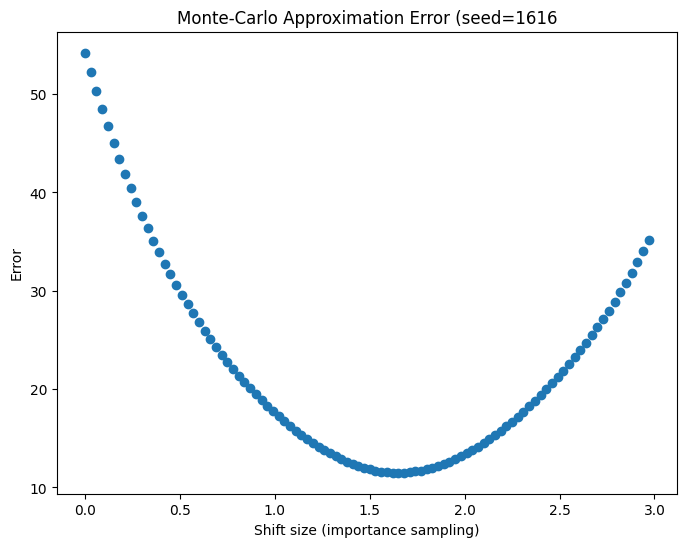

In [1]:
import ImportanceSamplingExperiment as bswm
a = bswm.ImportanceSamplingExperiment()
a.plot()

| **Variable / Concept** | **Definition** | **Formula / Usage** | **Key Notes** |
|----------------|-------------|---------------|--------------|
| $ x $ | Original standard normal variable (no shift) | $ x \sim N(0,1) $ from `norm.ppf(uniform)` | Base before any modification. |
| ⚠ $ y $ | Shifted standard normal variable | $ y = x + \text{shift} $ | ⚠ Mistake noted: Thought it was the weight; it's the shifted variable used for payoff and weight. |
| **Underlying** $ S_T $ | Stock price at maturity | $ S_T = S_0 \cdot e^{rT - 0.5\sigma^2 T + \sigma\sqrt{T} \, y} $ | Volatility and drift applied to $ y $. |
| Discounted payoff | Present value of the option payoff | $ \max(S_T - K, 0) \cdot e^{-rT} $ | Net benefit of the option at t=0. |
| ⚠ *Weight* $ w(y) $ | Density correction factor: $ f(y) / g(y) $ | $ w(y) = e^{-y^2/2 + (y - \text{shift})^2/2} $ | ⚠ Does **not** change variance directly; adjusts for the mean shift in the standard normal. |
| Weighted value | Contribution of each simulation | $ \text{value} = \text{payoffDiscounted} \cdot w(y) $ | Accumulated to estimate the expected value. |
| Monte Carlo estimator | Mean of weighted values | $ \hat{V} = \frac{1}{N} \sum_{i=1}^N \text{value}_i $ | Approximated price using IS. |
| Monte Carlo error | RMS difference vs analytic value | $ \text{error} = \sqrt{\frac{1}{N} \sum ( \text{value}_i - V_{\text{analytic}} )^2} $ | Compares accuracy with and without IS. |
| ⚠ Importance of $|h(x)|$ | Relevance for variance and convergence | When changing density, $|h(x)|$ ensures integrability | ⚠ Mistake noted: Thought it wasn’t mandatory, but it is in IS theory. |
| Optimal shift | Shift that minimizes variance | Depends on event rarity and shape of $h(x)$ | Error vs shift graph should be convex. |
